In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
from analysis import completeExtract
savF = True

In [2]:
import imageio.v2 as imageio
from pathlib import Path
import os

## Individual Resonators
Experimental

In [4]:
res_filenames = [
    "separateResonators/one_dot_offset/TDUJNF_VNA_tracedata.h5",  # resonator 1
    "separateResonators/two_dot_offset/TDUK07_VNA_tracedata.h5"   # resonator 2
]

one_dot_offset: f_res = 4.7489 GHz | FWHM = 95.39 MHz | HWHM = 47.69 MHz
two_dot_offset: f_res = 4.7577 GHz | FWHM = 93.93 MHz | HWHM = 46.97 MHz


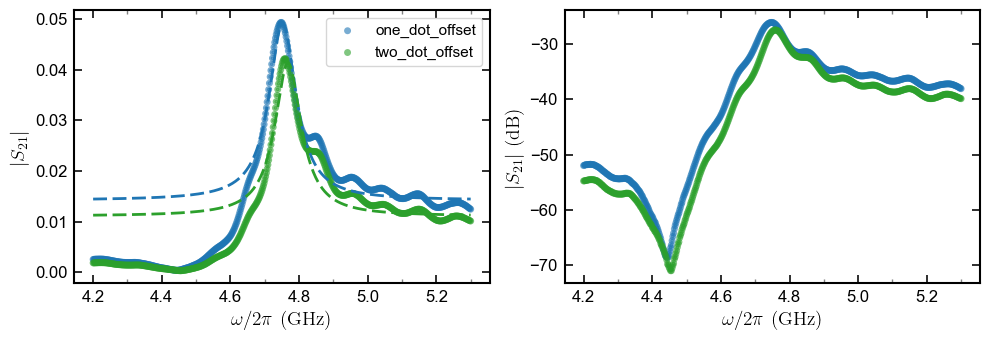

In [ ]:
from scipy.optimize import curve_fit

def lorentzian(f, f0, delta_f, A, C):
    return C + A / (1 + ((f - f0) / (delta_f / 2))**2)

colors = ['#1f76b4', '#2ca02c']
results = []

for filepath, color in zip(res_filenames, colors):
    with h5py.File(filepath, 'r') as f:
        amplitude = np.array(f['entry']['data0']['amplitude'])
        frequencyGHz = np.array(f['entry']['data0']['frequency']) / 1e9

    if amplitude.ndim == 2:
        amplitude = amplitude[-1]
    amplitude_dB = 20 * np.log10(np.abs(amplitude))

    mask = frequencyGHz >= 4.6
    freq = frequencyGHz[mask]
    amp_lin = amplitude[mask]

    peak_idx = np.argmax(amp_lin)
    f_res_exp = freq[peak_idx]

    x_fit = np.linspace(frequencyGHz[0], frequencyGHz[-1], 500)

    try:
        popt, _ = curve_fit(lorentzian, freq, amp_lin,
                            p0=[f_res_exp, 0.05,
                                np.max(amp_lin) - np.min(amp_lin),
                                np.min(amp_lin)])
        _, delta_f, _, _ = popt
        hwhm_MHz = abs(delta_f) / 2 * 1000
        fit_lin = lorentzian(x_fit, *popt)
        fit_ok = True
        print(f"{filepath.split('/')[-2]}: f_res = {f_res_exp:.4f} GHz | FWHM = {abs(delta_f)*1000:.2f} MHz | HWHM = {hwhm_MHz:.2f} MHz")
    except Exception as e:
        fit_ok = False
        fit_lin = None
        print(f"Fit failed: {e}")

    label = filepath.split('/')[-2]
    results.append(dict(frequencyGHz=frequencyGHz, amplitude=amplitude,
                        amplitude_dB=amplitude_dB, x_fit=x_fit,
                        fit_lin=fit_lin, fit_ok=fit_ok, color=color, label=label))

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(axis='both', direction='in', width=1.15, pad=5, length=6,
                   labelsize=12, right=True, top=True)
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.tick_params(which='minor', direction='in', width=1, length=3,
                   right=True, top=True, color='gray')

# combined: linear (left) | dB (right)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.5))
for r in results:
    axL.scatter(r['frequencyGHz'], r['amplitude'], color=r['color'], s=25, alpha=0.6, edgecolor='none', label=r['label'])
    axL.scatter(r['frequencyGHz'], r['amplitude'], edgecolors=r['color'], facecolors='none', s=2.5, alpha=0.6)
    if r['fit_ok']:
        axL.plot(r['x_fit'], r['fit_lin'], color=r['color'], linestyle='--', dashes=(5, 2), linewidth=2)
    axR.scatter(r['frequencyGHz'], r['amplitude_dB'], color=r['color'], s=25, alpha=0.6, edgecolor='none', label=r['label'])
    axR.scatter(r['frequencyGHz'], r['amplitude_dB'], edgecolors=r['color'], facecolors='none', s=2.5, alpha=0.6)
axL.set_xlabel(r'$\omega / 2\pi$ (GHz)', fontsize=14, usetex=True)
axL.set_ylabel(r'$|S_{21}|$', fontsize=14, usetex=True)
axL.legend(fontsize=11)
axR.set_xlabel(r'$\omega / 2\pi$ (GHz)', fontsize=14, usetex=True)
axR.set_ylabel(r'$|S_{21}|$ (dB)', fontsize=14, usetex=True)
style_ax(axL)
style_ax(axR)
plt.tight_layout()
plt.show()

# Circle Fit

/Users/albanjoseph/Documents/PhD/projects/timeDomain/analysis/circuit.py:319: RuntimeWarning: invalid value encountered in sqrt
  R_err = self.r0 * np.sqrt(b**2 - np.sin(self.phi)**2)


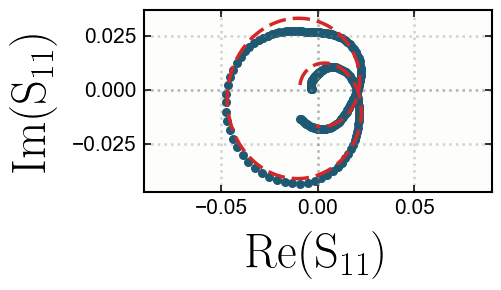

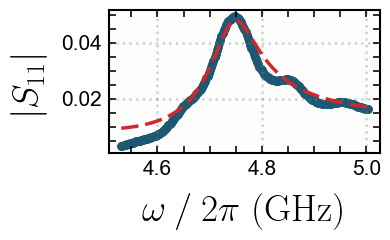

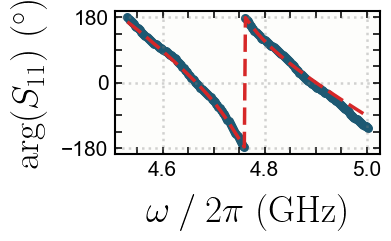

Delay = 2.168194850818703e-09 
Impedance = -0.5141762964362804 
Delay left = 1.148568797681012e-10 
fr = 4.7436 GHz 
Qi = -39.3 
Qc = 22.1 
QL = 50.5 
FWHM (loaded) = 93.9479 MHz 
FWHM (internal) = -120.6414 MHz 
FWHM (coupling) = 214.5894 MHz


In [6]:
# --- resonator 1 ---
filepath = res_filenames[0]
with h5py.File(filepath, 'r') as f:
    amplitude = np.array(f['entry']['data0']['amplitude'])
    phase     = np.array(f['entry']['data0']['phase'])
    frequencyGHz = np.array(f['entry']['data0']['frequency']) / 1e9

if amplitude.ndim == 2:
    amplitude = amplitude[-1]
    phase     = phase[-1]

storePort = completeExtract.circleStore(
    phase,
    frequencyGHz * 1e9,
    amplitude,
    method='gradient',
    port_type='reflection',
    start_idx=150,
    end_idx=365,
    grad_start_idx=0,
    grad_end_idx=10,
    grad_adjustment=-1.75
)
# Plot complex plane (circle fit)
fig, ax = plt.subplots(figsize=(5, 3))
fig, ax = storePort.plot_s11_complex(fig=fig, ax=ax)
ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.set_ylabel("Im(S$_{11}$)", usetex=True, fontsize=35)
ax.set_xlabel("Re(S$_{11}$)", usetex=True, fontsize=35)
ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
ax.set_xlim(-0.09, 0.09)
ax.tick_params(axis='both', labelsize=15)
plt.tight_layout()
if savF:
    plt.savefig('separateResonators/images/oneDot_busResonance_circleFit.png', dpi=300)
plt.show()

# Plot magnitude (linear)
fig, ax = plt.subplots(figsize=(4, 2.5))
fig, ax = storePort.plot_s11_magnitude_linear(fig=fig, ax=ax)
ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(direction='in', which='both', top=True, right=True,
               bottom=True, left=True, width=1.15, labelsize=15)
ax.minorticks_on()
ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
plt.ylabel(r'$|S_{11}|$', rotation=90, usetex=True)
plt.tight_layout()
if savF:
    plt.savefig('separateResonators/images/oneDot_busResonance_magnitude.png', dpi=300)
plt.show()


# Plot phase
fig, ax = plt.subplots(figsize=(4, 2.5))
fig, ax = storePort.plot_s11_phase(fig=fig, ax=ax)
ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(direction='in', which='both', top=True, right=True,
               bottom=True, left=True, width=1.15, labelsize=15)
ax.minorticks_on()
ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
plt.ylabel(r'arg($S_{11}$) ($^\circ$)', usetex=True)
plt.tight_layout()
if savF:
    plt.savefig('separateResonators/images/oneDot_busResonance_phase.png', dpi=300)
plt.show()

storePort.print_summary()

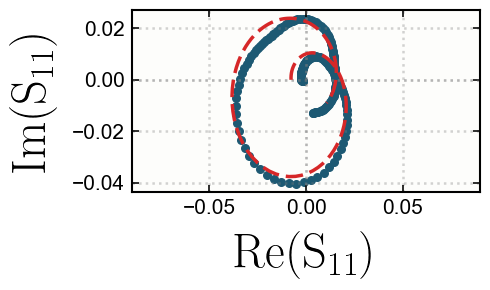

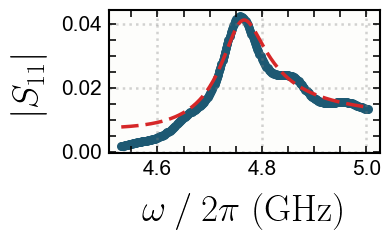

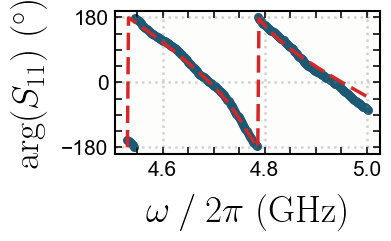

Delay = 1.8828743375282516e-09 
Impedance = -0.4782785255611235 
Delay left = 1.21866955752835e-10 
fr = 4.7608 GHz 
Qi = -39.3 
Qc = 23.1 
QL = 56.0 
FWHM (loaded) = 85.0776 MHz 
FWHM (internal) = -121.2245 MHz 
FWHM (coupling) = 206.3021 MHz


In [7]:
# --- resonator 2 ---
filepath = res_filenames[1]
with h5py.File(filepath, 'r') as f:
    amplitude = np.array(f['entry']['data0']['amplitude'])
    phase     = np.array(f['entry']['data0']['phase'])
    frequencyGHz = np.array(f['entry']['data0']['frequency']) / 1e9

if amplitude.ndim == 2:
    amplitude = amplitude[-1]
    phase     = phase[-1]

storePort = completeExtract.circleStore(
    phase,
    frequencyGHz * 1e9,
    amplitude,
    method='gradient',
    port_type='reflection',
    start_idx=150,
    end_idx=365,
    grad_start_idx=0,
    grad_end_idx=10,
    grad_adjustment=-1.75
)
# Plot complex plane (circle fit)
fig, ax = plt.subplots(figsize=(5, 3))
fig, ax = storePort.plot_s11_complex(fig=fig, ax=ax)
ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.set_ylabel("Im(S$_{11}$)", usetex=True, fontsize=35)
ax.set_xlabel("Re(S$_{11}$)", usetex=True, fontsize=35)
ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
ax.set_xlim(-0.09, 0.09)
ax.tick_params(axis='both', labelsize=15)
plt.tight_layout()
if savF:
    plt.savefig('separateResonators/images/twoDot_busResonance_circleFit.png', dpi=300)
plt.show()

# Plot magnitude
# fig, ax = plt.subplots(figsize=(4, 2.5))
# fig, ax = storePort.plot_s11_magnitude(fig=fig, ax=ax)
# ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
# for spine in ax.spines.values():
#     spine.set_linewidth(1.5)
# ax.tick_params(direction='in', which='both', top=True, right=True,
#                bottom=True, left=True, width=1.15, labelsize=15)
# ax.minorticks_on()
# ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
# plt.ylabel(r'$|S_{11}|$ (dB)', rotation=90, usetex=True)
# plt.tight_layout()
# plt.show()


# Plot magnitude (linear)
fig, ax = plt.subplots(figsize=(4, 2.5))
fig, ax = storePort.plot_s11_magnitude_linear(fig=fig, ax=ax)
ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(direction='in', which='both', top=True, right=True,
               bottom=True, left=True, width=1.15, labelsize=15)
ax.minorticks_on()
ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
plt.ylabel(r'$|S_{11}|$', rotation=90, usetex=True)
plt.tight_layout()
if savF:
    plt.savefig('separateResonators/images/twoDot_busResonance_magnitude.png', dpi=300)
plt.show()

# Plot phase
fig, ax = plt.subplots(figsize=(4, 2.5))
fig, ax = storePort.plot_s11_phase(fig=fig, ax=ax)
ax.grid(True, color='grey', linestyle=':', linewidth=1.8, alpha=0.35)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(direction='in', which='both', top=True, right=True,
               bottom=True, left=True, width=1.15, labelsize=15)
ax.minorticks_on()
ax.set_facecolor((0.976, 0.965, 0.925, 0.2))
plt.ylabel(r'arg($S_{11}$) ($^\circ$)', usetex=True)
plt.tight_layout()
if savF:
    plt.savefig('separateResonators/images/twoDot_busResonance_phase.png', dpi=300)
plt.show()

storePort.print_summary()